# End-to-End Showcase of the Compression Pipeline

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

from src.data import load_clip, save_clip, print_json_structure, extract_tracks

from src.cagd.lspia.solver import LSPIASolver
from src.cagd.lspia.initializer import SimpleInitializer
from src.cagd.lspia.knot_topo import BoehmKnotOptimizer

from src.compression.clip import ClipCompressor
from src.compression.baseline import RawBase64Compressor, QuantizeCompressor
from src.compression.blendshapes import BlendShapesSchemeCompressor
from src.compression.quaternions import QuaternionsSchemeCompressor

from src.eval import memory_saving_matrix, plot_memory_usage_matrix

In [3]:
CLIP_IDX = 481

In [4]:
COMPRESSORS = {
    # Original
    "Original": dict(
        compressor=None,
        path=f"data/json/clip_{CLIP_IDX}.json",
    ),

    # baseline
    "RawBase64": dict(
        compressor = ClipCompressor(
            blendshapes_compressor=RawBase64Compressor(type_name="number"),
            quaternions_compressor=RawBase64Compressor(type_name="quaternion"),
        ),
        path=f"out/rb64/clip_{CLIP_IDX}_rb64.json",
    ),
    "Direct Quantize": dict(
        compressor = ClipCompressor(
            blendshapes_compressor=QuantizeCompressor(type_name="number"),
            quaternions_compressor=QuantizeCompressor(type_name="quaternion", renormalize=True),
        ),
        path=f"out/quan/clip_{CLIP_IDX}_quan.json",
    ),

    # proposed schemes
    "Blendshapes Scheme": dict(
        compressor = ClipCompressor(
            blendshapes_compressor=BlendShapesSchemeCompressor(type_name="number", decimation_thres=0),
            quaternions_compressor=QuantizeCompressor(type_name="quaternion", renormalize=True),
        ),
        path=f"out/bsqq/clip_{CLIP_IDX}_bsqq.json",
    ),
    "Grand Scheme (No PCA)": dict(
        compressor = ClipCompressor(
            blendshapes_compressor=BlendShapesSchemeCompressor(type_name="number", decimation_thres=0),
            quaternions_compressor=QuaternionsSchemeCompressor(type_name="quaternion", pca_on_hands=False, bake_fps=30, solver=LSPIASolver(
                degree=3, initial_num_cps=10,
                initializer=SimpleInitializer(),
                knot_topo=BoehmKnotOptimizer(tolerance=1e-3, max_insertion_per_step=3),
                max_iters=100, convergence_iters=20, macro_iters=10, tolerance=1e-3,
            )),
        ),
        path=f"out/sch1/clip_{CLIP_IDX}_sch1.json",
    ),
    "Grand Scheme (PCA)": dict(
        compressor = ClipCompressor(
            blendshapes_compressor=BlendShapesSchemeCompressor(type_name="number", decimation_thres=0),
            quaternions_compressor=QuaternionsSchemeCompressor(type_name="quaternion", pca_on_hands=True, bake_fps=30, solver=LSPIASolver(
                degree=3, initial_num_cps=10,
                initializer=SimpleInitializer(),
                knot_topo=BoehmKnotOptimizer(tolerance=1e-3, max_insertion_per_step=3),
                max_iters=100, convergence_iters=20, macro_iters=10, tolerance=1e-3,
            )),
        ),
        path=f"out/sch2/clip_{CLIP_IDX}_sch2.json",
    ),
}

# Processing

### Load Test Clip

In [5]:
orig_path = f"data/json/clip_{CLIP_IDX}.json"
orig_clip = load_clip(orig_path)

### Compressions

In [6]:
results_clips = dict()

for name, data in COMPRESSORS.items():
    if name == "Original":
        continue
    
    start = time.perf_counter()
    results_clips[name] = data["compressor"].compress(orig_clip)
    save_clip(results_clips[name], data["path"])
    end = time.perf_counter()
    print(f"elapse {end - start:.6f} s: {name}")

elapse 0.063410 s: RawBase64
elapse 0.073816 s: Direct Quantize
elapse 0.517018 s: Blendshapes Scheme
elapse 9.701482 s: Grand Scheme (No PCA)
elapse 5.450261 s: Grand Scheme (PCA)


# Evaluation

In [7]:
print("===== MEMOEY USAGES =====\n")
for name, data in COMPRESSORS.items():
    if name == "Original":
        blendshapes = extract_tracks(orig_clip["animationClip"]["tracks"], type="number")
        quaternions = extract_tracks(orig_clip["animationClip"]["tracks"], type="quaternion")

    else:
        clip = results_clips[name]
        blendshapes = clip["animationClip"].pop("blendshape_tracks_data", None)
        quaternions = clip["animationClip"].pop("quaternion_tracks_data", None)

    save_clip(blendshapes, "out/temp/blendshapes.json")
    save_clip(quaternions, "out/temp/quaternions.json")
    blendshapes_size = os.path.getsize("out/temp/blendshapes.json") // 1024
    quaternions_size = os.path.getsize("out/temp/quaternions.json") // 1024
    ratio = blendshapes_size / (blendshapes_size + quaternions_size)

    str1 = f"{name:<25} : {f"{os.path.getsize(data["path"]) // 1024:,}" + " KB":<10} | "
    str2 = f" blendshapes size: {f"{blendshapes_size:,}" + " KB":<9} | "
    str3 = f" quaternions size: {f"{quaternions_size:,}" + " KB":<9} | "
    str4 = f"({round(100 * ratio)} / {round(100 * (1 - ratio))})"

    print(str1 + str2 + str3 + str4)

===== MEMOEY USAGES =====

Original                  : 3,769 KB   |  blendshapes size: 1,371 KB  |  quaternions size: 1,666 KB  | (45 / 55)
RawBase64                 : 991 KB     |  blendshapes size: 455 KB    |  quaternions size: 529 KB    | (46 / 54)
Direct Quantize           : 238 KB     |  blendshapes size: 104 KB    |  quaternions size: 109 KB    | (49 / 51)
Blendshapes Scheme        : 175 KB     |  blendshapes size: 50 KB     |  quaternions size: 109 KB    | (31 / 69)
Grand Scheme (No PCA)     : 157 KB     |  blendshapes size: 50 KB     |  quaternions size: 85 KB     | (37 / 63)
Grand Scheme (PCA)        : 93 KB      |  blendshapes size: 50 KB     |  quaternions size: 32 KB     | (61 / 39)


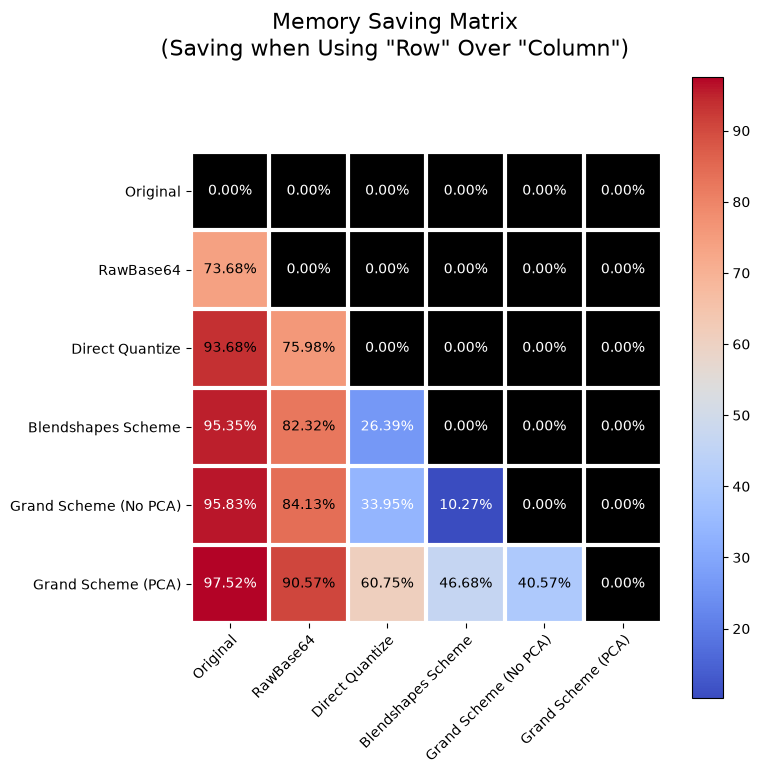

In [13]:
matrix = memory_saving_matrix(
    paths=[data["path"] for data in COMPRESSORS.values()], 
    names=[name for name in COMPRESSORS.keys()], 
    clip_negs=True
    )
plot_memory_usage_matrix(matrix)